# 02. Post-Training Subset Evaluation: Perplexity & Loss

This notebook visualizes post-training validation perplexity and cross-entropy loss metrics computed across Bangla (`bng`), English (`eng`), and Parallel Translation (`translation`) evaluation subsets.

In [1]:
import os
import yaml
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

## 1. Load Evaluation YAML Report

Loads structured evaluation results from `saved/reports/eval_results.yaml`.

In [2]:
report_paths = [
    "../saved/reports/eval_results.yaml",
    "saved/reports/eval_results.yaml"
]

report_file = None
for p in report_paths:
    if os.path.exists(p):
        report_file = p
        break

if report_file is not None:
    with open(report_file, "r", encoding="utf-8") as f:
        results = yaml.safe_load(f).get("evaluations", {})
    df = pd.DataFrame.from_dict(results, orient="index")
else:
    df = pd.DataFrame()

df

,total_loss,ce_loss,z_loss,perplexity,batches
translation,1.4982,1.4976,0.0006,4.4708,3618
eng,2.9216,2.9203,0.0013,18.5464,25000
bng,3.3228,3.3220,0.0009,27.7152,50000
overall,2.5809,2.5800,0.0009,16.9108,78618


## 2. Subset Perplexity & Cross-Entropy Visualization

Comparison of cross-entropy loss and perplexity across `translation`, `eng`, `bng`, and `overall` evaluation splits.

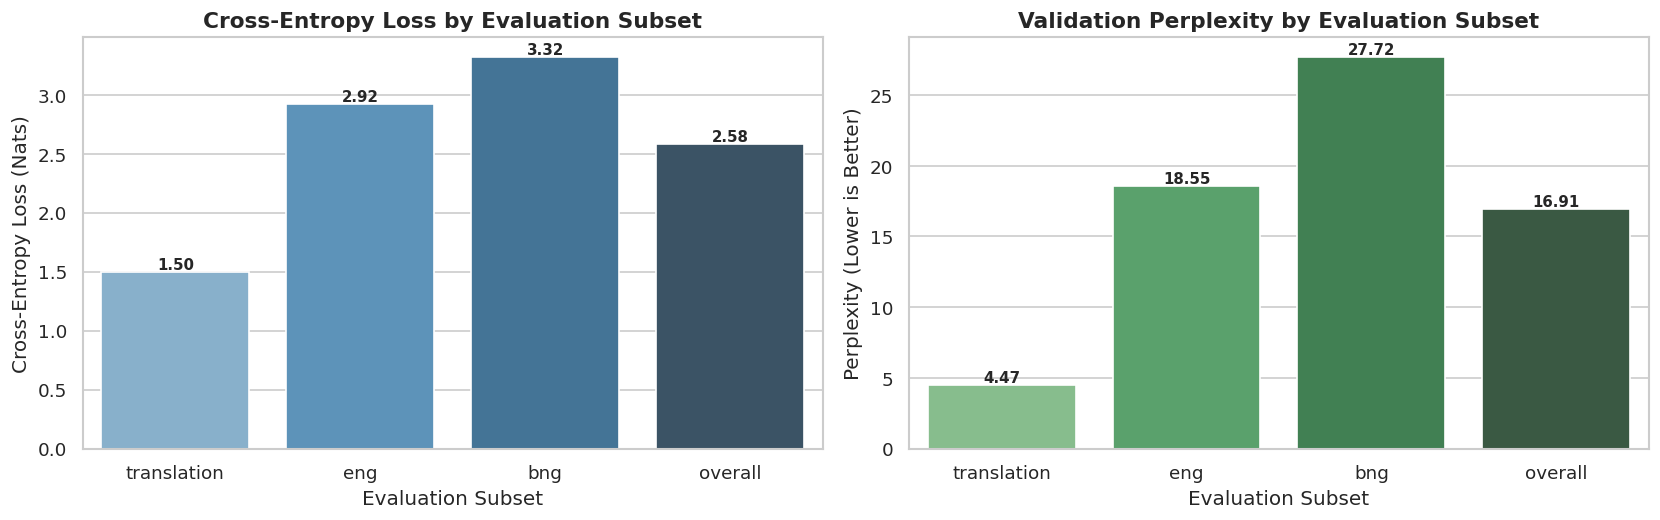

In [3]:
if not df.empty and "perplexity" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    
    sns.barplot(x=df.index, y="ce_loss", hue=df.index, legend=False, data=df, ax=axes[0], palette="Blues_d")
    axes[0].set_title("Cross-Entropy Loss by Evaluation Subset", fontsize=13, fontweight="bold")
    axes[0].set_ylabel("Cross-Entropy Loss (Nats)")
    axes[0].set_xlabel("Evaluation Subset")
    for p in axes[0].patches:
        h = p.get_height()
        axes[0].annotate(f"{h:.2f}", (p.get_x() + p.get_width() / 2., h), ha="center", va="bottom", fontsize=9, fontweight="bold")
        
    sns.barplot(x=df.index, y="perplexity", hue=df.index, legend=False, data=df, ax=axes[1], palette="Greens_d")
    axes[1].set_title("Validation Perplexity by Evaluation Subset", fontsize=13, fontweight="bold")
    axes[1].set_ylabel("Perplexity (Lower is Better)")
    axes[1].set_xlabel("Evaluation Subset")
    for p in axes[1].patches:
        h = p.get_height()
        axes[1].annotate(f"{h:.2f}", (p.get_x() + p.get_width() / 2., h), ha="center", va="bottom", fontsize=9, fontweight="bold")
        
    plt.tight_layout()
    plt.show()